# Experiment 02 - Coexistence, uniform persistence, and Lyapunov functions

Paper sections reproduced: Section 3, Theorem 3.1, Theorem 3.2, Theorem 3.4.

This notebook visualizes the coexistence equilibrium `P3`, tests several initial conditions, and plots Lyapunov functions used for global stability of boundary subsystems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root, brentq

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

def monod(u, a, b):
    return a * u / (b + u)

def monod_inv(D, a, b):
    return b * D / (a - D)

def rhs(t, U, p):
    S, x, y, z = U
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    return [1 - S - f1*x, x*(f1-p["D1"]) - f2*y, y*(f2-p["D2"]) - f3*z, z*(f3-p["D3"])]

def simulate(p, U0, T=250):
    return solve_ivp(lambda t, U: rhs(t, U, p), (0, T), U0, dense_output=True, max_step=0.05, rtol=1e-8, atol=1e-10)

def find_P3(p):
    y3 = monod_inv(p["D3"], p["a3"], p["b3"])
    def equations(V):
        S, x = V
        f1 = monod(S, p["a1"], p["b1"])
        f2 = monod(x, p["a2"], p["b2"])
        return [S + f1*x - 1, x*(f1-p["D1"]) - f2*y3]
    sol = root(equations, (0.25, 0.6))
    if not sol.success:
        raise RuntimeError(sol.message)
    S3, x3 = sol.x
    z3 = y3 * (monod(x3, p["a2"], p["b2"]) - p["D2"]) / p["D3"]
    return np.array([S3, x3, y3, z3])

def plot_timeseries(sol, title):
    t = np.linspace(sol.t[0], sol.t[-1], 3000)
    vals = sol.sol(t)
    plt.figure()
    for row, label in zip(vals, ["S", "x", "y", "z"]):
        plt.plot(t, row, label=label)
    plt.xlabel("time")
    plt.ylabel("state")
    plt.title(title)
    plt.legend()
    plt.show()
    return t, vals

## Experiment 1: coexistence equilibrium P3

Equivalent to Theorem 3.4 and the discussion after it. All species remain positive in the long run.

P3 = [0.06685199 1.62912887 0.16666667 0.39632626]


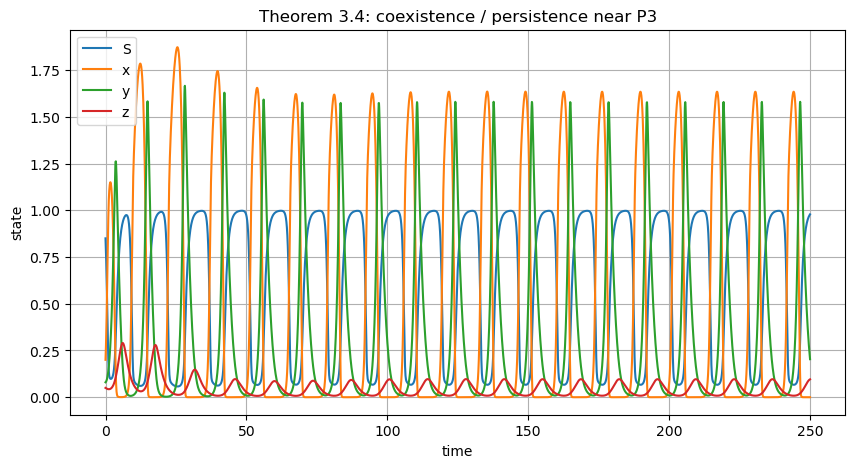

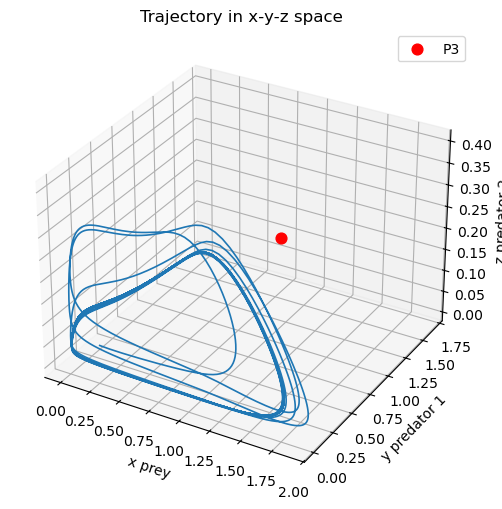

In [2]:
p = dict(a1=4.0, b1=0.4, a2=2.0, b2=0.3, a3=1.4, b3=0.3, D1=0.4, D2=0.5, D3=0.5)
P3 = find_P3(p)
print("P3 =", P3)

sol = simulate(p, U0=(0.85, 0.2, 0.08, 0.05), T=250)
t, vals = plot_timeseries(sol, "Theorem 3.4: coexistence / persistence near P3")

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(vals[1], vals[2], vals[3], lw=1.2)
ax.scatter([P3[1]], [P3[2]], [P3[3]], color="red", s=60, label="P3")
ax.set_xlabel("x prey")
ax.set_ylabel("y predator 1")
ax.set_zlabel("z predator 2")
ax.set_title("Trajectory in x-y-z space")
ax.legend()
plt.show()

## Experiment 2: uniform persistence from many initial conditions

Equivalent to Theorem 3.4. We start from multiple positive initial states and inspect the long-run lower envelope of `x,y,z`.

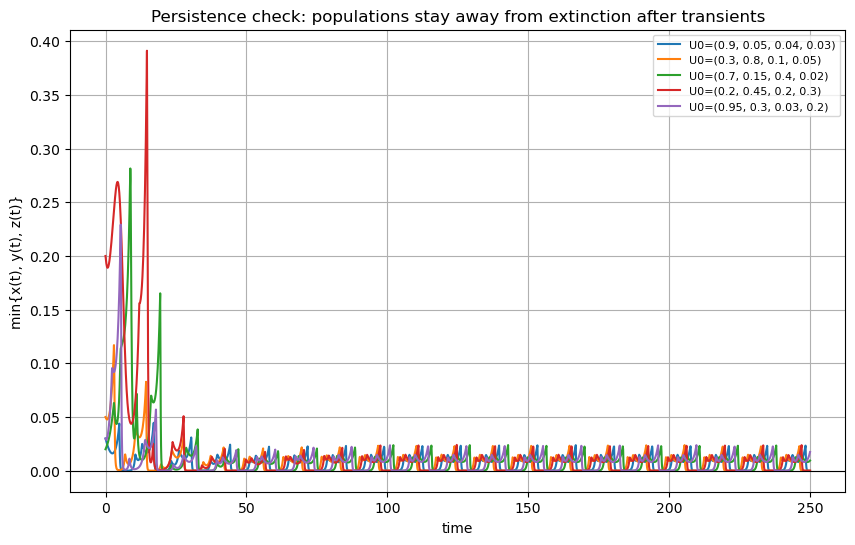

In [3]:
initial_conditions = [
    (0.90, 0.05, 0.04, 0.03),
    (0.30, 0.80, 0.10, 0.05),
    (0.70, 0.15, 0.40, 0.02),
    (0.20, 0.45, 0.20, 0.30),
    (0.95, 0.30, 0.03, 0.20),
]

plt.figure(figsize=(10, 6))
for U0 in initial_conditions:
    sol = simulate(p, U0=U0, T=250)
    t = np.linspace(0, 250, 2500)
    vals = sol.sol(t)
    lower = np.min(vals[1:4], axis=0)
    plt.plot(t, lower, label=f"U0={U0}")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("time")
plt.ylabel("min{x(t), y(t), z(t)}")
plt.title("Persistence check: populations stay away from extinction after transients")
plt.legend(fontsize=8)
plt.show()

## Experiment 3: Lyapunov function for P1

Equivalent to Theorem 3.1. The paper uses a quadratic Lyapunov function on the `(S,x)` subsystem. Here we plot it along a trajectory when P1 is stable.

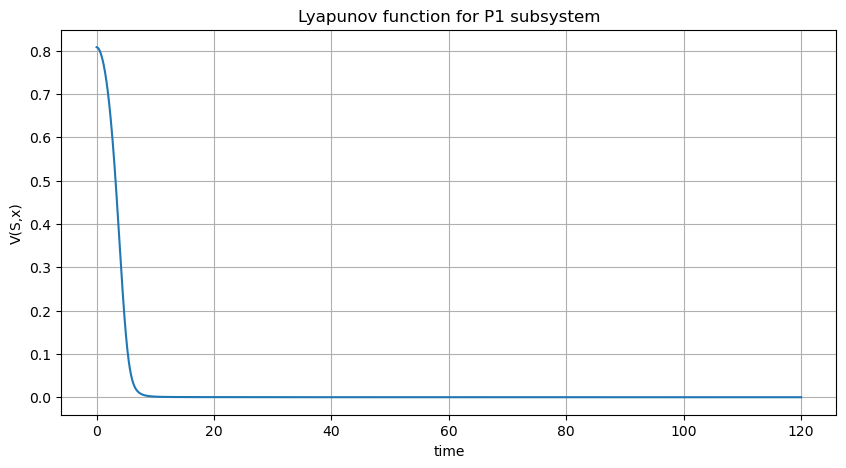

P1 = (0.21538461538461537, 1.120879120879121, 0, 0) final V = 1.7686071342207996e-07


In [4]:
p_P1 = dict(a1=2.0, b1=0.4, a2=0.6, b2=0.5, a3=1.0, b3=0.4, D1=0.7, D2=0.45, D3=0.5)
S1 = monod_inv(p_P1["D1"], p_P1["a1"], p_P1["b1"])
x1 = (1 - S1) / p_P1["D1"]
sol = simulate(p_P1, U0=(0.9, 0.05, 0.25, 0.05), T=120)
t = np.linspace(0, 120, 2000)
S, x, y, z = sol.sol(t)
V = 0.5 * (S - S1)**2 + 0.5 * (x - x1)**2

plt.figure()
plt.plot(t, V)
plt.xlabel("time")
plt.ylabel("V(S,x)")
plt.title("Lyapunov function for P1 subsystem")
plt.show()

print("P1 =", (S1, x1, 0, 0), "final V =", V[-1])

## Experiment 4: Lyapunov function for P2

Equivalent to Theorem 3.2. The paper uses an entropy-like term for nutrient and quadratic terms for prey and predator 1.

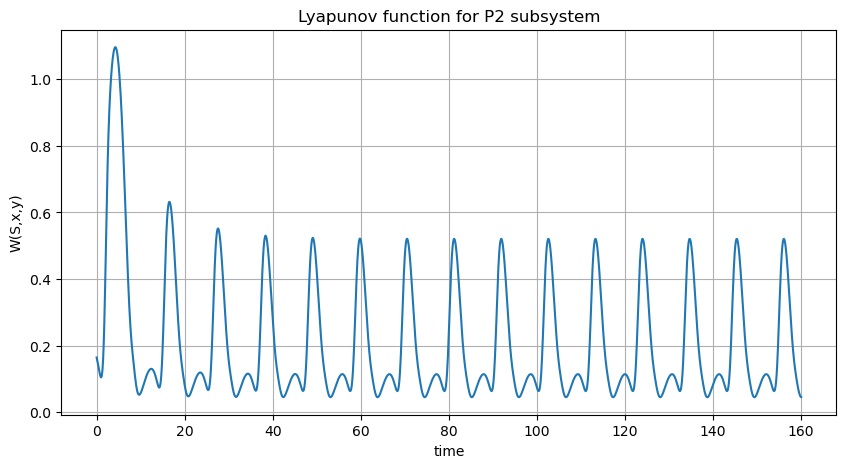

P2 = (0.6056116265125947, 0.24, 0.45731395581234413, 0) final W = 0.04525832979415158


In [5]:
p_P2 = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
x2 = monod_inv(p_P2["D2"], p_P2["a2"], p_P2["b2"])
def eq_S2(S):
    return S + monod(S, p_P2["a1"], p_P2["b1"]) * x2 - 1
S2 = brentq(eq_S2, 1e-8, 1.0)
y2 = x2 * (monod(S2, p_P2["a1"], p_P2["b1"]) - p_P2["D1"]) / p_P2["D2"]

sol = simulate(p_P2, U0=(0.95, 0.1, 0.05, 0.2), T=160)
t = np.linspace(0, 160, 2500)
S, x, y, z = sol.sol(t)
W = S - S2 - S2 * np.log(S / S2) + 0.5 * (x - x2)**2 + 0.5 * (y - y2)**2

plt.figure()
plt.plot(t, W)
plt.xlabel("time")
plt.ylabel("W(S,x,y)")
plt.title("Lyapunov function for P2 subsystem")
plt.show()

print("P2 =", (S2, x2, y2, 0), "final W =", W[-1])